In [4]:
## For using EigenMaps a) decompose the joint library and b) filter for shared and differential mechanisms between HepG2 (Liver Hepatocyte) and K562 (blood fibroblast)

In [5]:
## Load joint library DeepSHAP maps for two cell lines
import os, sys, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Populate precomputed attributions
raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

print(f'{len(df)} seqs loaded')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs loaded


In [ ]:
## Eigen decompose entire library
em.eigendecompose(enhancer_only=True)

ei1_vecs = np.array([r['eigenvectors'][:, 0] for r in em.eigen_results])
ei1_var = np.array([r['var_ratio'][0] for r in em.eigen_results])
print(f'Done. EI_1 var: mean={ei1_var.mean():.1%}, median={np.median(ei1_var):.1%}')

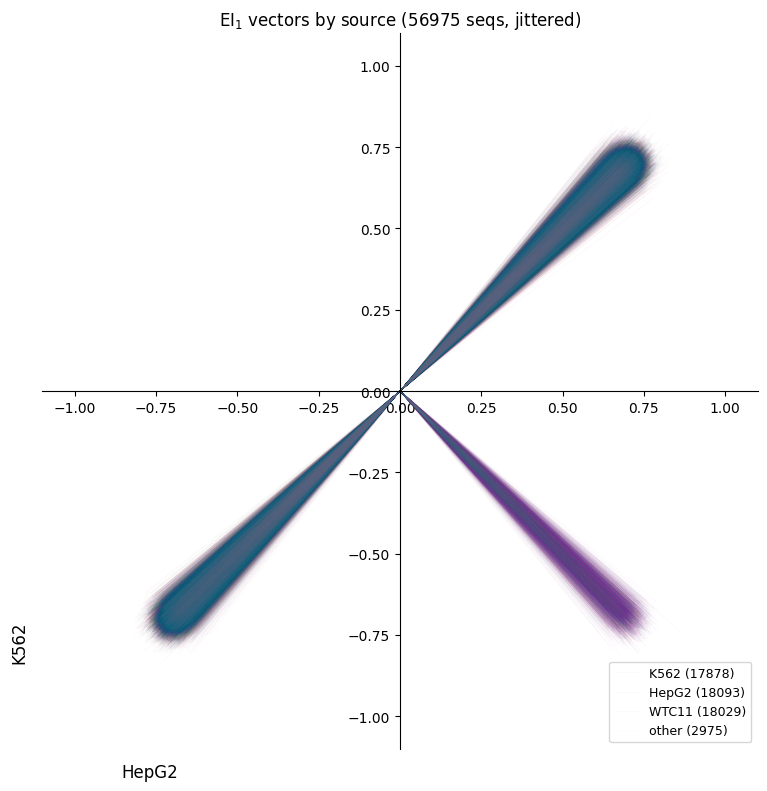

In [32]:
## Plot EI_1 vectors colored by source
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

jitter = np.random.default_rng(42).normal(0, 0.03, ei1_vecs.shape)
vecs_j = ei1_vecs + jitter

# Source from sequence name prefix
source = df['name'].str.split('_').str[0]
source_colors = {'K562': '#E53935', 'HepG2': '#8E24AA', 'WTC11': '#00897B'}

fig, ax = plt.subplots(figsize=(8, 8))
for src, color in source_colors.items():
    mask = source == src
    if mask.sum() == 0: continue
    segs = [[(0, 0), (v[1], v[0])] for v in vecs_j[mask]]  # HepG2=x, K562=y
    lc = LineCollection(segs, colors=color, alpha=0.03, linewidths=0.5, label=f'{src} ({mask.sum()})')
    ax.add_collection(lc)

# Other sources
other = ~source.isin(source_colors.keys())
if other.sum() > 0:
    segs = [[(0, 0), (v[1], v[0])] for v in vecs_j[other]]
    lc = LineCollection(segs, colors='gray', alpha=0.03, linewidths=0.5, label=f'other ({other.sum()})')
    ax.add_collection(lc)

ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('HepG2', fontsize=12); ax.set_ylabel('K562', fontsize=12)
ax.xaxis.set_label_coords(0.15, -0.02)
ax.yaxis.set_label_coords(-0.02, 0.15)
ax.legend(fontsize=9, markerscale=5, loc='lower right')
ax.set_title(f'EI$_1$ vectors by source ({len(ei1_vecs)} seqs, jittered)')
plt.tight_layout(); plt.show()


--- Shared (EI$_1$ > 80%) | seq 53351: HepG2_DNasePeakNoPromoter13098 ---
    K562: actual=-0.35 pred=-0.35 err=0.00
    HepG2: actual=-0.73 pred=-0.73 err=0.00
    EI_1 var=90.9%, vec=[0.70710677 0.7071068 ]

--- Mixed (EI$_1$ ~ 50%) | seq 44857: HepG2_DNasePeakNoPromoter40840 ---
    K562: actual=-0.33 pred=-0.34 err=0.01
    HepG2: actual=-0.60 pred=-0.60 err=0.00
    EI_1 var=50.6%, vec=[-0.70710933  0.70710427]
Opposing (EI$_1$ < 40%): no sequences found


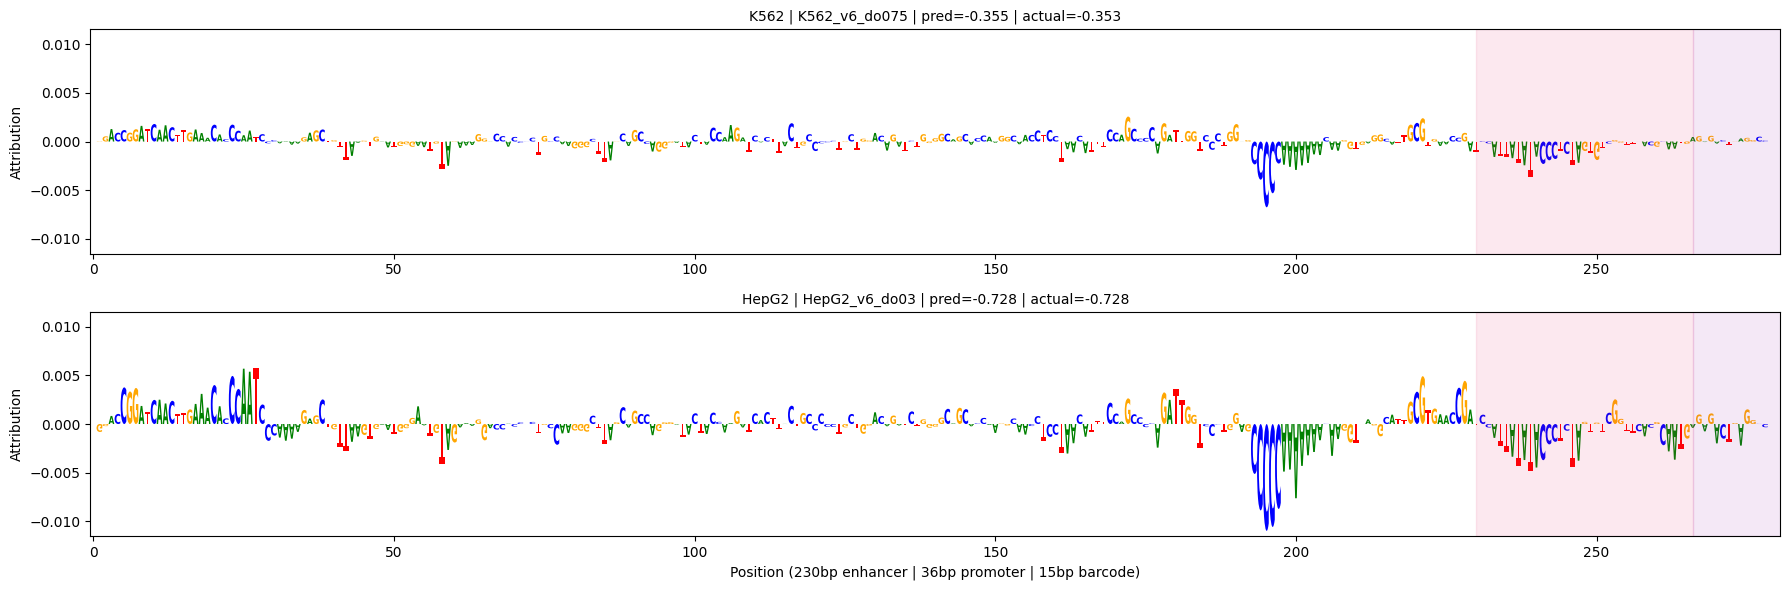

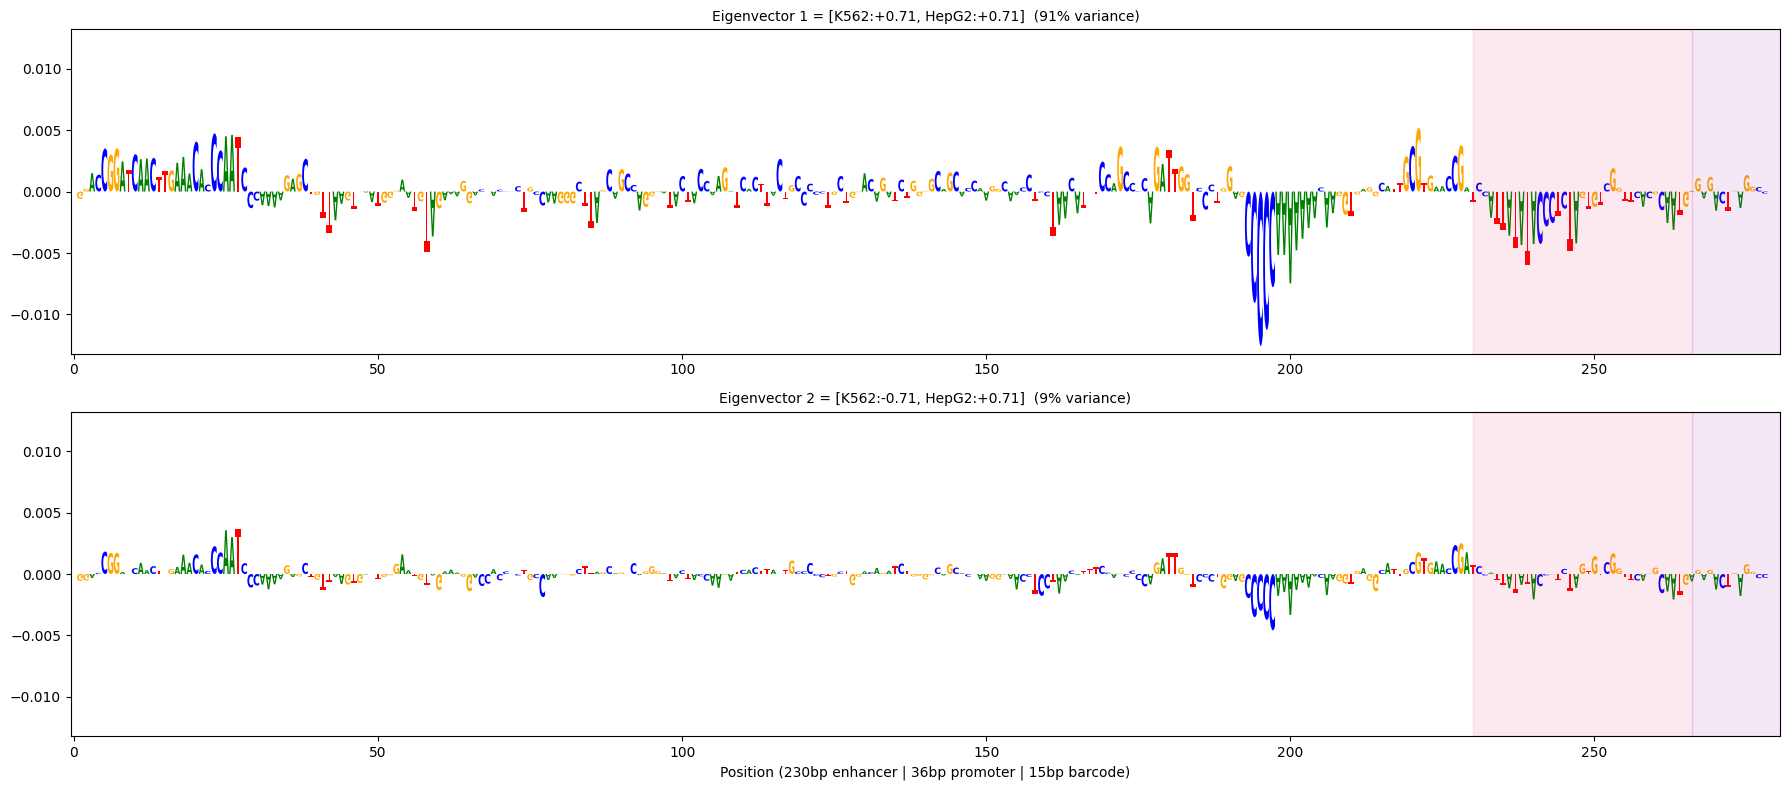

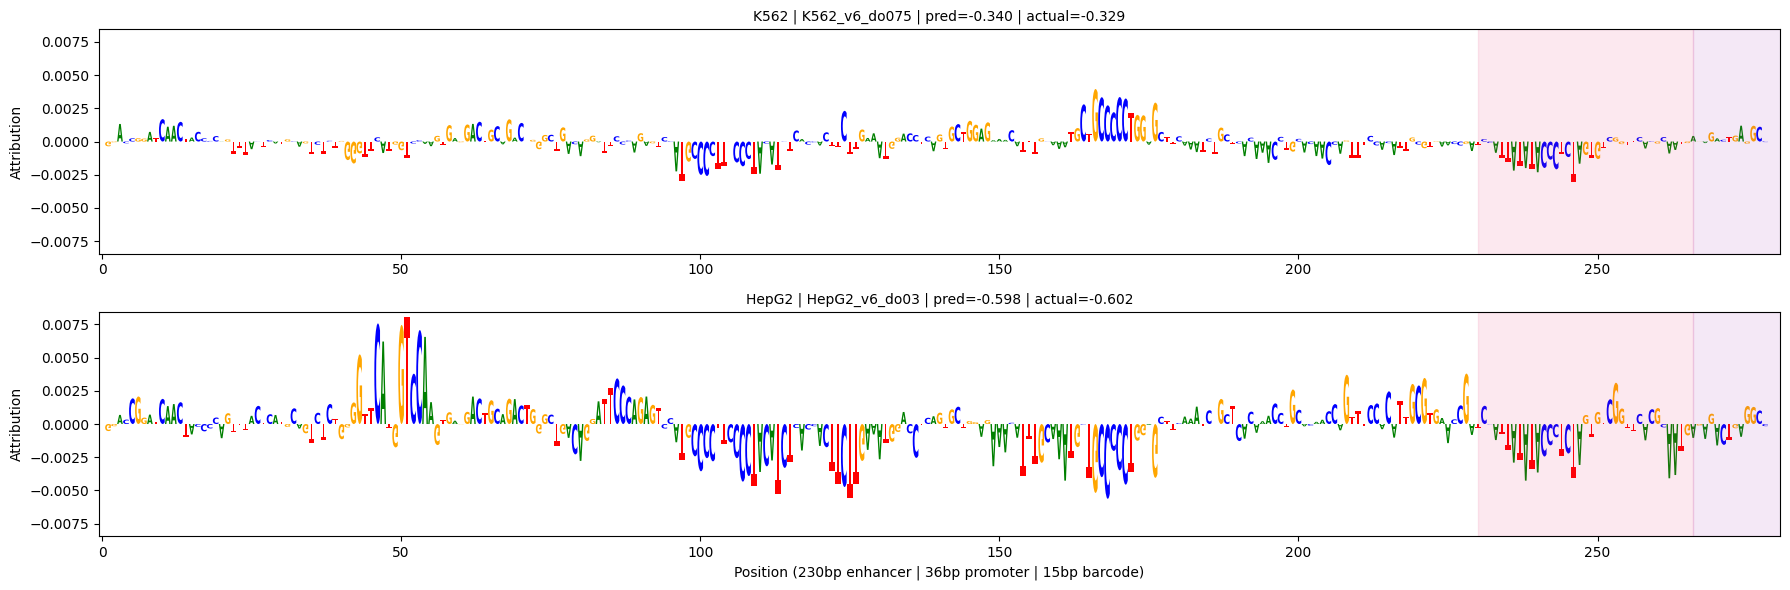

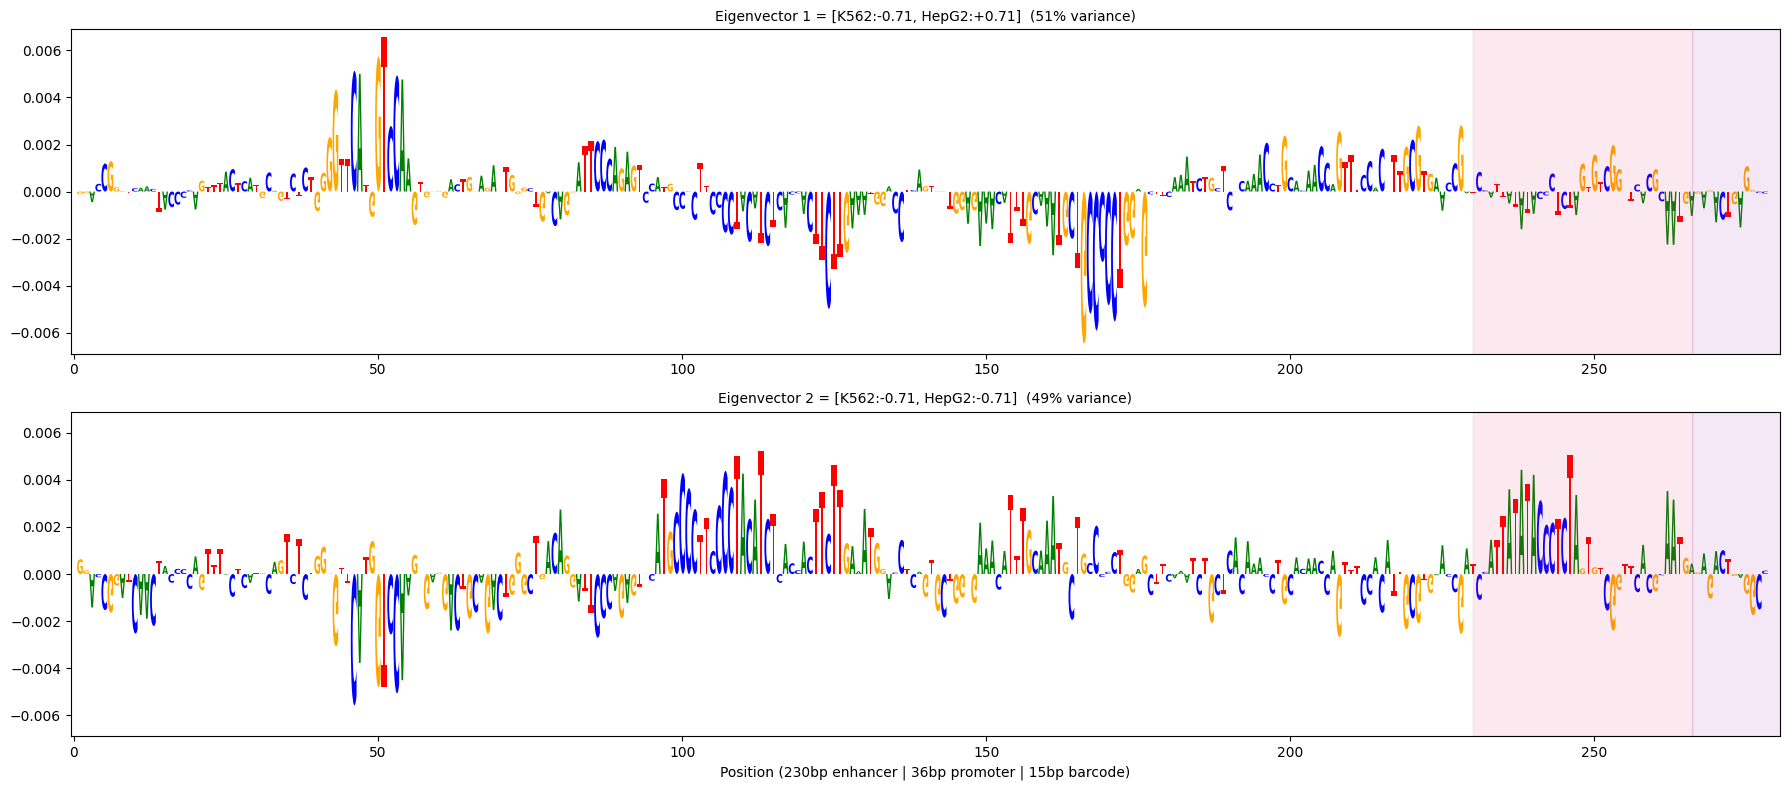

In [30]:
## Show EI logos for one seq from each variance-split regime (well-predicted)
# High EI_1 var = shared motifs, 50/50 split = independent, high EI_2 var = opposing
mse = np.mean([(em.predictions[ct] - df[f'{ct}_log2FC'].values)**2 for ct in CT], axis=0)
good = mse < np.percentile(mse, 25)  # top 25% best-predicted

bins = [
    ('Shared (EI$_1$ > 80%)', (ei1_var > 0.8) & good),
    ('Mixed (EI$_1$ ~ 50%)', (ei1_var > 0.45) & (ei1_var < 0.55) & good),
    ('Opposing (EI$_1$ < 40%)', (ei1_var < 0.4) & good),
]

for label, mask in bins:
    if mask.sum() == 0:
        print(f'{label}: no sequences found'); continue
    idx = np.where(mask)[0][np.argmin(mse[mask])]
    print(f'\n--- {label} | seq {idx}: {df.iloc[idx]["name"][:60]} ---')
    for ct in CT:
        a = df.iloc[idx][f'{ct}_log2FC']; p = em.predictions[ct][idx]
        print(f'    {ct}: actual={a:.2f} pred={p:.2f} err={abs(a-p):.2f}')
    print(f'    EI_1 var={ei1_var[idx]:.1%}, vec={ei1_vecs[idx]}')
    em.plot_attr_logos(seq_idx=idx)
    em.plot_eigen_logos(seq_idx=idx)

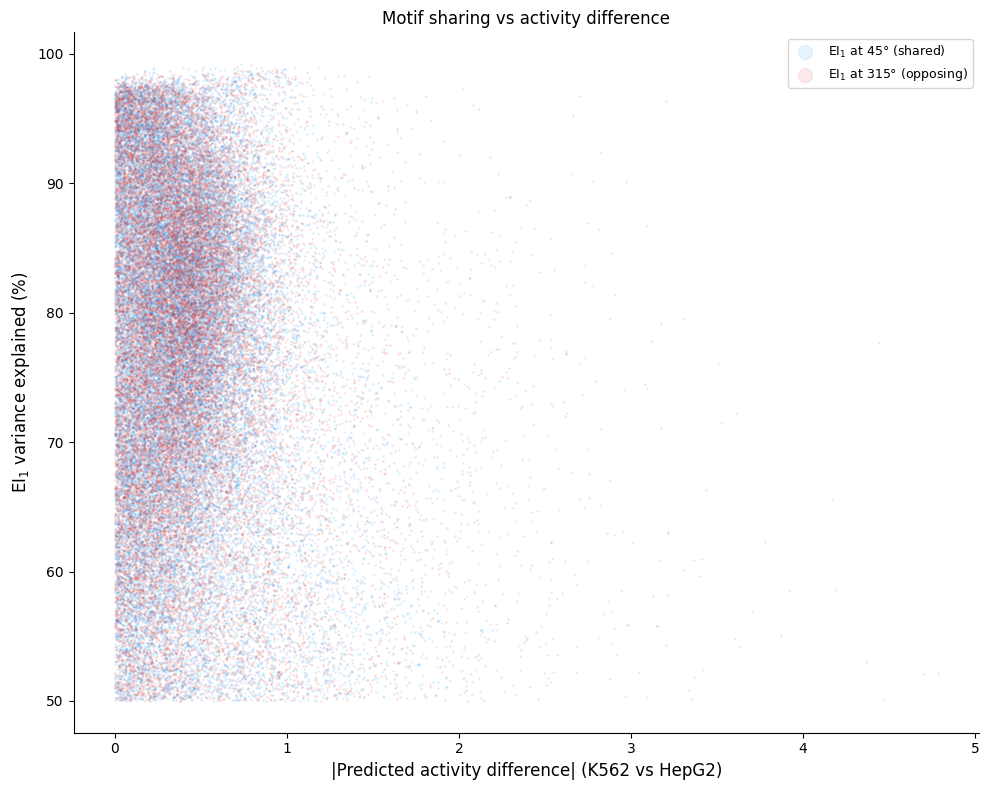

EI_1 at 45° (shared): 32234 (56.6%)
EI_1 at 315° (opposing): 24741 (43.4%)


In [35]:
## 2D space: EI_1 variance explained vs |activity difference|, colored by EI_1 direction
import matplotlib.pyplot as plt

activity_diff = np.abs(em.predictions['K562'] - em.predictions['HepG2'])

# EI_1 direction: dot with shared diagonal — positive = shared (45°), negative = opposing (315°)
shared_dir = np.array([1, 1]) / np.sqrt(2)
dots = ei1_vecs @ shared_dir
is_shared = dots > 0  # True = 45°, False = 315°

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(activity_diff[is_shared], ei1_var[is_shared] * 100,
           s=1, alpha=0.1, c='#2196F3', rasterized=True, label='EI$_1$ at 45\u00b0 (shared)')
ax.scatter(activity_diff[~is_shared], ei1_var[~is_shared] * 100,
           s=1, alpha=0.1, c='#E53935', rasterized=True, label='EI$_1$ at 315\u00b0 (opposing)')

ax.set_xlabel('|Predicted activity difference| (K562 vs HepG2)', fontsize=12)
ax.set_ylabel('EI$_1$ variance explained (%)', fontsize=12)
ax.set_title('Motif sharing vs activity difference', fontsize=12)
ax.legend(fontsize=9, markerscale=10, framealpha=0.8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(f'EI_1 at 45\u00b0 (shared): {is_shared.sum()} ({is_shared.mean():.1%})')
print(f'EI_1 at 315\u00b0 (opposing): {(~is_shared).sum()} ({(~is_shared).mean():.1%})')

In [8]:
## threshold selection for number of shared vs divergent seqs (same motifs same directions, same motifs different directions, randomly sampled from same motifs some shared directions)